# Notebook 14: Semantic Channel Detection — Auto-Classify Your Media Columns

Real marketing datasets have messy column names: `fb_spend_q4`, `Google_Ads_search_cost`, `tv_national_grps`. Instead of manually labeling each one, we can use **semantic matching** to auto-detect channel types from raw column names.

This notebook builds a lightweight string-matching engine (no ML libraries needed) that:
1. Tokenizes column names into meaningful parts
2. Matches tokens against a predefined taxonomy of 13 channel categories
3. Detects metric types (spend, impressions, clicks, GRPs)
4. Returns confidence scores so you know which matches to trust

**Dependencies**: Only `numpy`, `pandas`, `matplotlib`, and Python stdlib (`difflib`, `re`).

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import re
import os
from difflib import SequenceMatcher
from collections import OrderedDict

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC',
    'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#D0D7DE',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#D0D7DE',
})

COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

os.makedirs('images', exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1. The Channel Taxonomy

We define 13 marketing channel categories. Each has a set of keywords that commonly appear in column names for that channel. The taxonomy is based on the channel categories used in Simba's semantic matcher.

In [2]:
CHANNEL_TAXONOMY = OrderedDict([
    ('Paid Search',    ['google', 'search', 'sem', 'ppc', 'adwords', 'keywords']),
    ('Paid Social',    ['facebook', 'instagram', 'meta', 'social', 'tiktok', 'snapchat', 'pinterest', 'fb']),
    ('Display',        ['display', 'banner', 'programmatic', 'dv360', 'gdn']),
    ('Video / OLV',    ['youtube', 'video', 'olv', 'streaming', 'ctv', 'ott']),
    ('TV',             ['tv', 'television', 'linear', 'broadcast', 'cable', 'national_tv']),
    ('Radio',          ['radio', 'audio', 'spotify', 'podcast']),
    ('Print',          ['print', 'newspaper', 'magazine', 'press']),
    ('OOH',            ['ooh', 'outdoor', 'billboard', 'transit']),
    ('Email',          ['email', 'edm', 'newsletter', 'crm']),
    ('Direct Mail',    ['mail', 'dm', 'direct_mail', 'catalog']),
    ('Affiliate',      ['affiliate', 'referral', 'partner']),
    ('PR',             ['pr', 'press_release', 'earned']),
    ('Brand / TM',     ['brand', 'trademark', 'branded']),
])

# Print a summary
for cat, kws in CHANNEL_TAXONOMY.items():
    print(f'{cat:16s}  keywords: {", ".join(kws)}')

Paid Search       keywords: google, search, sem, ppc, adwords, keywords
Paid Social       keywords: facebook, instagram, meta, social, tiktok, snapchat, pinterest, fb
Display           keywords: display, banner, programmatic, dv360, gdn
Video / OLV       keywords: youtube, video, olv, streaming, ctv, ott
TV                keywords: tv, television, linear, broadcast, cable, national_tv
Radio             keywords: radio, audio, spotify, podcast
Print             keywords: print, newspaper, magazine, press
OOH               keywords: ooh, outdoor, billboard, transit
Email             keywords: email, edm, newsletter, crm
Direct Mail       keywords: mail, dm, direct_mail, catalog
Affiliate         keywords: affiliate, referral, partner
PR                keywords: pr, press_release, earned
Brand / TM        keywords: brand, trademark, branded


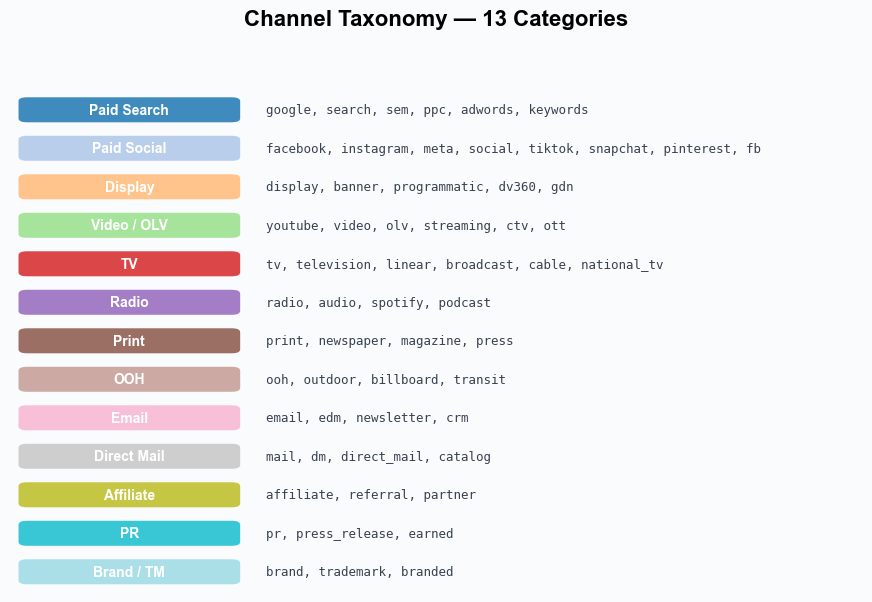

Saved images/14_channel_taxonomy.png


In [3]:
# --- Reference Card: Channel Taxonomy ---
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(CHANNEL_TAXONOMY) + 1)
ax.axis('off')
ax.set_title('Channel Taxonomy — 13 Categories', fontsize=16, fontweight='bold', pad=20)

palette = plt.cm.tab20(np.linspace(0, 1, 13))

for i, (cat, kws) in enumerate(reversed(list(CHANNEL_TAXONOMY.items()))):
    y = i + 0.5
    color = palette[12 - i]
    # Category badge
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.2, y - 0.2), 2.4, 0.45, boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='none', alpha=0.85
    ))
    ax.text(1.4, y + 0.02, cat, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    # Keywords
    kw_str = ', '.join(kws)
    ax.text(3.0, y + 0.02, kw_str, ha='left', va='center',
            fontsize=9, color='#374151', family='monospace')

fig.savefig('images/14_channel_taxonomy.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved images/14_channel_taxonomy.png')

![Channel Taxonomy](./images/14_channel_taxonomy.png)

*Reference card showing all 13 channel categories and their associated keywords.*

---
## 2. Metric Type Detection

Beyond the channel, we also want to know *what kind of metric* the column represents — spend, impressions, clicks, or GRPs.

In [4]:
METRIC_TYPES = OrderedDict([
    ('Spend',       ['spend', 'cost', 'budget', 'investment', 'dollars', 'expenditure']),
    ('Impressions',  ['impressions', 'imps', 'views', 'reach', 'exposure']),
    ('Clicks',       ['clicks', 'visits', 'sessions', 'traffic']),
    ('GRPs',         ['grps', 'trps', 'ratings', 'points']),
])

for mt, kws in METRIC_TYPES.items():
    print(f'{mt:14s}  keywords: {", ".join(kws)}')

Spend           keywords: spend, cost, budget, investment, dollars, expenditure
Impressions     keywords: impressions, imps, views, reach, exposure
Clicks          keywords: clicks, visits, sessions, traffic
GRPs            keywords: grps, trps, ratings, points


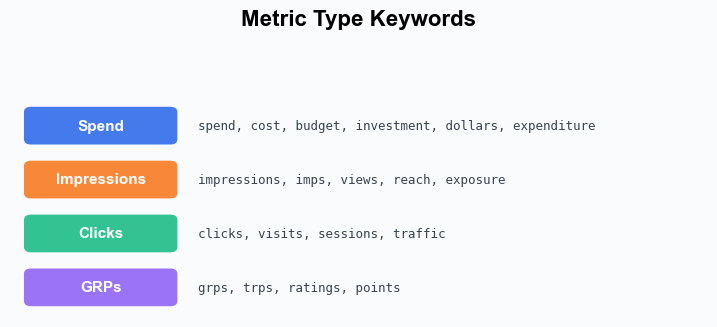

Saved images/14_metric_types.png


In [5]:
# --- Reference Card: Metric Types ---
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(METRIC_TYPES) + 1)
ax.axis('off')
ax.set_title('Metric Type Keywords', fontsize=16, fontweight='bold', pad=16)

metric_colors = [COLORS[0], COLORS[1], COLORS[2], COLORS[4]]

for i, ((mt, kws), color) in enumerate(zip(reversed(list(METRIC_TYPES.items())), reversed(metric_colors))):
    y = i + 0.5
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.3, y - 0.2), 2.0, 0.5, boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='none', alpha=0.85
    ))
    ax.text(1.3, y + 0.05, mt, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(2.7, y + 0.05, ', '.join(kws), ha='left', va='center',
            fontsize=9, color='#374151', family='monospace')

fig.savefig('images/14_metric_types.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved images/14_metric_types.png')

![Metric Types](./images/14_metric_types.png)

*Metric type keywords used to distinguish spend from impressions from clicks from GRPs.*

---
## 3. The Matching Algorithm — Step by Step

The algorithm has three stages:

1. **Tokenize** the column name into meaningful parts
2. **Score** each token against every keyword in the taxonomy
3. **Rank** categories by their best match score

Let's walk through an example with the column name `Google_Ads_search_cost`.

In [6]:
def tokenize(column_name: str) -> list[str]:
    """Split a column name into tokens.
    
    Handles underscores, hyphens, spaces, and camelCase.
    Strips trailing digits (like year suffixes).
    """
    # Insert space before uppercase letters for camelCase
    name = re.sub(r'([a-z])([A-Z])', r'\1 \2', column_name)
    # Replace separators with spaces
    name = re.sub(r'[_\-/]+', ' ', name)
    # Split and lowercase
    tokens = [t.lower().strip() for t in name.split() if t.strip()]
    # Remove pure numeric tokens (years, week numbers, etc.)
    tokens = [t for t in tokens if not t.isdigit()]
    return tokens


# Walk through the example
example = 'Google_Ads_search_cost'
tokens = tokenize(example)
print(f'Column:  {example}')
print(f'Tokens:  {tokens}')

Column:  Google_Ads_search_cost
Tokens:  ['google', 'ads', 'search', 'cost']


In [7]:
def score_token(token: str, keyword: str) -> float:
    """Compute a similarity score between a token and a keyword.
    
    Returns a score from 0.0 to 1.0 using three methods:
    1. Exact match → 1.0
    2. Substring containment → 0.85
    3. SequenceMatcher similarity → actual ratio
    
    Takes the maximum of all three.
    """
    if token == keyword:
        return 1.0
    if keyword in token or token in keyword:
        return 0.85
    return SequenceMatcher(None, token, keyword).ratio()


# Demo: score each token against Paid Search keywords
print(f'Scoring tokens {tokens} against Paid Search keywords:\n')
for token in tokens:
    for kw in CHANNEL_TAXONOMY['Paid Search']:
        s = score_token(token, kw)
        if s > 0.4:
            print(f'  "{token}" vs "{kw}"  →  {s:.2f}')

Scoring tokens ['google', 'ads', 'search', 'cost'] against Paid Search keywords:

  "google" vs "google"  →  1.00
  "ads" vs "adwords"  →  0.60
  "search" vs "search"  →  1.00
  "search" vs "sem"  →  0.44


In [8]:
def match_category(tokens: list[str], taxonomy: dict) -> tuple[str, float]:
    """Find the best-matching category for a set of tokens.
    
    For each category, computes the maximum score across all
    (token, keyword) pairs. Returns (category_name, best_score).
    """
    best_cat = 'Unknown'
    best_score = 0.0
    
    for category, keywords in taxonomy.items():
        cat_score = 0.0
        for token in tokens:
            for keyword in keywords:
                s = score_token(token, keyword)
                cat_score = max(cat_score, s)
        if cat_score > best_score:
            best_score = cat_score
            best_cat = category
    
    return best_cat, best_score


# Full walkthrough for our example
channel, ch_score = match_category(tokens, CHANNEL_TAXONOMY)
metric, mt_score = match_category(tokens, METRIC_TYPES)

print(f'Column:   {example}')
print(f'Tokens:   {tokens}')
print(f'Channel:  {channel} (confidence: {ch_score:.0%})')
print(f'Metric:   {metric} (confidence: {mt_score:.0%})')

Column:   Google_Ads_search_cost
Tokens:   ['google', 'ads', 'search', 'cost']
Channel:  Paid Search (confidence: 100%)
Metric:   Spend (confidence: 100%)


---
## 4. Implementation — The Full SemanticMatcher

Now we wrap everything into a clean, reusable class.

In [9]:
class SemanticMatcher:
    """Classify column names into marketing channel categories and metric types.
    
    Uses token-based string matching with substring and SequenceMatcher scoring.
    No ML dependencies — only Python stdlib + pandas.
    
    Parameters
    ----------
    channel_taxonomy : dict, optional
        Mapping of channel category names to keyword lists.
        Defaults to the standard 13-category taxonomy.
    metric_types : dict, optional
        Mapping of metric type names to keyword lists.
        Defaults to Spend/Impressions/Clicks/GRPs.
    min_confidence : float, optional
        Minimum score to consider a match valid. Default 0.5.
    """
    
    def __init__(self, channel_taxonomy=None, metric_types=None, min_confidence=0.5):
        self.channel_taxonomy = channel_taxonomy or CHANNEL_TAXONOMY
        self.metric_types = metric_types or METRIC_TYPES
        self.min_confidence = min_confidence
    
    @staticmethod
    def tokenize(column_name: str) -> list[str]:
        """Split a column name into lowercase tokens."""
        name = re.sub(r'([a-z])([A-Z])', r'\1 \2', column_name)
        name = re.sub(r'[_\-/]+', ' ', name)
        tokens = [t.lower().strip() for t in name.split() if t.strip()]
        tokens = [t for t in tokens if not t.isdigit()]
        return tokens
    
    @staticmethod
    def score_token(token: str, keyword: str) -> float:
        """Similarity score between a token and keyword (0 to 1)."""
        if token == keyword:
            return 1.0
        if keyword in token or token in keyword:
            return 0.85
        return SequenceMatcher(None, token, keyword).ratio()
    
    def _match(self, tokens: list[str], taxonomy: dict) -> tuple[str, float]:
        """Find the best match in a taxonomy for a list of tokens."""
        best_cat = 'Unknown'
        best_score = 0.0
        for category, keywords in taxonomy.items():
            cat_score = 0.0
            for token in tokens:
                for keyword in keywords:
                    s = self.score_token(token, keyword)
                    cat_score = max(cat_score, s)
            if cat_score > best_score:
                best_score = cat_score
                best_cat = category
        return best_cat, best_score
    
    def classify(self, column_name: str) -> dict:
        """Classify a single column name.
        
        Returns a dict with keys:
            column, tokens, channel, channel_confidence,
            metric, metric_confidence
        """
        tokens = self.tokenize(column_name)
        channel, ch_score = self._match(tokens, self.channel_taxonomy)
        metric, mt_score = self._match(tokens, self.metric_types)
        
        if ch_score < self.min_confidence:
            channel = 'Unknown'
        if mt_score < self.min_confidence:
            metric = 'Unknown'
        
        return {
            'column': column_name,
            'tokens': tokens,
            'channel': channel,
            'channel_confidence': round(ch_score, 3),
            'metric': metric,
            'metric_confidence': round(mt_score, 3),
        }
    
    def classify_columns(self, columns: list[str]) -> pd.DataFrame:
        """Classify a list of column names. Returns a DataFrame."""
        results = [self.classify(col) for col in columns]
        df = pd.DataFrame(results)
        return df[['column', 'channel', 'channel_confidence', 'metric', 'metric_confidence']]


# Quick smoke test
matcher = SemanticMatcher()
result = matcher.classify('Google_Ads_search_cost')
print(result)

{'column': 'Google_Ads_search_cost', 'tokens': ['google', 'ads', 'search', 'cost'], 'channel': 'Paid Search', 'channel_confidence': 1.0, 'metric': 'Spend', 'metric_confidence': 1.0}


---
## 5. Testing on Sample Data

Let's run the matcher against the columns in `sample_mmm_weekly.csv` — a clean dataset with standard naming.

In [10]:
df_sample = pd.read_csv('data/sample_mmm_weekly.csv')
print(f'Columns: {list(df_sample.columns)}')

matcher = SemanticMatcher()
results = matcher.classify_columns(list(df_sample.columns))
results

Columns: ['date', 'revenue', 'tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend', 'competitor_spend', 'temperature', 'black_friday', 'christmas']


,column,channel,channel_confidence,metric,metric_confidence
0,date,Radio,0.545,Unknown,0.400
1,revenue,Unknown,0.400,Unknown,0.353
2,tv_spend,TV,1.000,Spend,1.000
3,facebook_spend,Paid Social,1.000,Spend,1.000
4,google_search_spend,Paid Search,1.000,Spend,1.000
5,radio_spend,Radio,1.000,Spend,1.000
6,print_spend,Print,1.000,Spend,1.000
7,competitor_spend,PR,0.545,Spend,1.000
8,temperature,Unknown,0.444,Spend,0.636
9,black_friday,Unknown,0.462,Clicks,0.545


The matcher correctly identifies the media channels and their metric types. Non-media columns like `date`, `revenue`, `temperature` get low confidence scores and are labeled as Unknown.

---
## 6. Testing on Messy Column Names

Real-world datasets are rarely clean. Let's test with 20 realistic messy column names.

In [11]:
messy_columns = [
    'FB_SPEND_2024',
    'google_ads_search_cost',
    'tv_national_grps_w1',
    'Instagram_Stories_Impressions',
    'yt_preroll_video_spend',
    'programmatic_display_imps',
    'spotify_audio_cost_usd',
    'ooh_billboards_q2',
    'EMAIL_NEWSLETTER_CLICKS',
    'direct_mail_catalog_spend',
    'affiliate_partner_revenue',
    'brand_search_cost',
    'tiktok_social_spend_daily',
    'radioNationalSpend',
    'print-newspaper-budget',
    'DV360_programmatic_spend',
    'CTV_streaming_impressions',
    'ppc_keywords_cost',
    'press_release_earned_views',
    'snapchat_spend_monthly',
]

matcher = SemanticMatcher()
messy_results = matcher.classify_columns(messy_columns)
messy_results

,column,channel,channel_confidence,metric,metric_confidence
0,FB_SPEND_2024,Paid Social,1.0,Spend,1.000
1,google_ads_search_cost,Paid Search,1.0,Spend,1.000
2,tv_national_grps_w1,TV,1.0,GRPs,1.000
3,Instagram_Stories_Impressions,Paid Social,1.0,Impressions,1.000
4,yt_preroll_video_spend,Video / OLV,1.0,Spend,1.000
5,programmatic_display_imps,Display,1.0,Impressions,1.000
6,spotify_audio_cost_usd,Radio,1.0,Spend,1.000
7,ooh_billboards_q2,OOH,1.0,Spend,0.588
8,EMAIL_NEWSLETTER_CLICKS,Email,1.0,Clicks,1.000
9,direct_mail_catalog_spend,Direct Mail,1.0,Spend,1.000


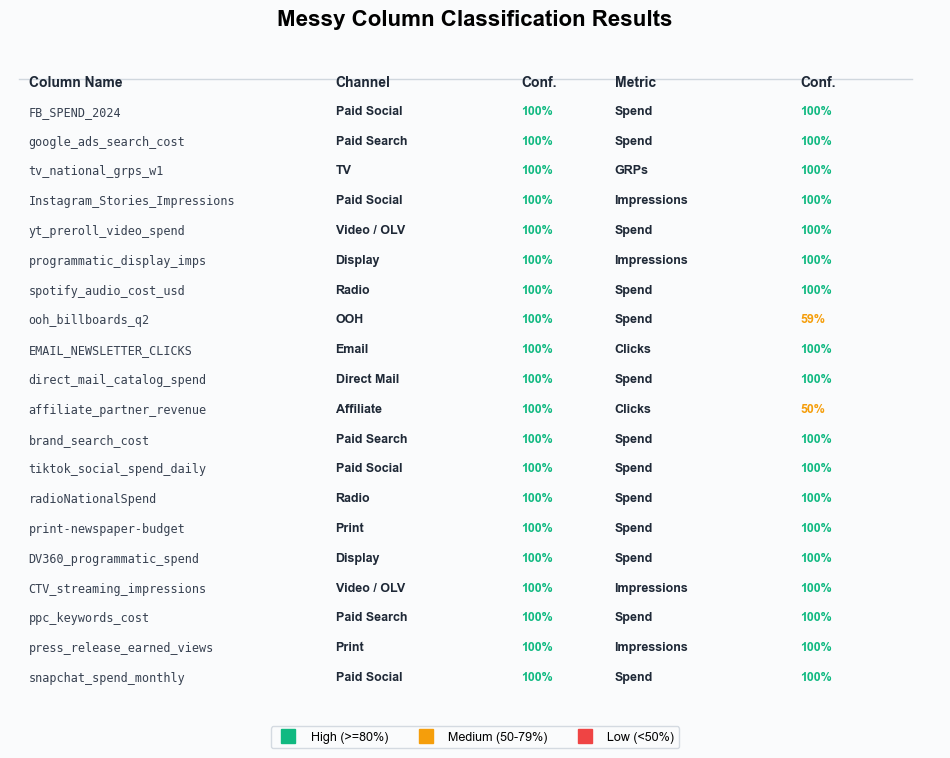

Saved images/14_messy_results.png


In [12]:
# --- Visualization: Color-coded confidence scores ---

def confidence_color(score):
    """Return green/yellow/red hex based on confidence score."""
    if score >= 0.8:
        return '#10B981'  # green
    elif score >= 0.5:
        return '#F59E0B'  # amber
    else:
        return '#EF4444'  # red


fig, ax = plt.subplots(figsize=(12, 9))
ax.axis('off')
ax.set_title('Messy Column Classification Results', fontsize=16, fontweight='bold', pad=16)

# Table header
headers = ['Column Name', 'Channel', 'Conf.', 'Metric', 'Conf.']
col_x = [0.02, 0.35, 0.55, 0.65, 0.85]
y_start = 0.96
row_h = 0.043

for j, h in enumerate(headers):
    ax.text(col_x[j], y_start, h, transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='#1F2937', va='top')

# Draw separator line using plot instead of axhline (avoids transform restriction)
ax.plot([0.01, 0.97], [0.955, 0.955], color='#D0D7DE',
        linewidth=1, transform=ax.transAxes, clip_on=False)

for i, row in messy_results.iterrows():
    y = y_start - (i + 1) * row_h
    ch_color = confidence_color(row['channel_confidence'])
    mt_color = confidence_color(row['metric_confidence'])
    
    ax.text(col_x[0], y, row['column'], transform=ax.transAxes,
            fontsize=8.5, color='#374151', va='top', family='monospace')
    ax.text(col_x[1], y, row['channel'], transform=ax.transAxes,
            fontsize=9, color='#1F2937', va='top', fontweight='bold')
    ax.text(col_x[2], y, f"{row['channel_confidence']:.0%}", transform=ax.transAxes,
            fontsize=9, color=ch_color, va='top', fontweight='bold')
    ax.text(col_x[3], y, row['metric'], transform=ax.transAxes,
            fontsize=9, color='#1F2937', va='top', fontweight='bold')
    ax.text(col_x[4], y, f"{row['metric_confidence']:.0%}", transform=ax.transAxes,
            fontsize=9, color=mt_color, va='top', fontweight='bold')

# Legend
for label, color in [('High (>=80%)', '#10B981'), ('Medium (50-79%)', '#F59E0B'), ('Low (<50%)', '#EF4444')]:
    ax.plot([], [], 's', color=color, markersize=10, label=label)
ax.legend(loc='lower center', ncol=3, frameon=True, fontsize=9,
          bbox_to_anchor=(0.5, -0.02))

fig.savefig('images/14_messy_results.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved images/14_messy_results.png')

![Messy Column Results](./images/14_messy_results.png)

*Classification results for 20 messy column names. Green scores indicate high-confidence matches that can be auto-assigned. Yellow or red scores should be flagged for human review.*

---
## 7. Confidence-Based Workflow

In practice, you want to **auto-assign** high-confidence matches and **flag** low-confidence ones for manual review. This saves time while ensuring accuracy.

In [13]:
HIGH_CONFIDENCE = 0.80
LOW_CONFIDENCE = 0.50

def triage_results(df: pd.DataFrame, score_col: str = 'channel_confidence'):
    """Split results into auto-assign, review, and unknown buckets."""
    auto = df[df[score_col] >= HIGH_CONFIDENCE]
    review = df[(df[score_col] >= LOW_CONFIDENCE) & (df[score_col] < HIGH_CONFIDENCE)]
    unknown = df[df[score_col] < LOW_CONFIDENCE]
    return auto, review, unknown

auto, review, unknown = triage_results(messy_results)

print(f'Auto-assign (>= {HIGH_CONFIDENCE:.0%}):  {len(auto)} columns')
print(f'Needs review ({LOW_CONFIDENCE:.0%}–{HIGH_CONFIDENCE:.0%}): {len(review)} columns')
print(f'Unknown (< {LOW_CONFIDENCE:.0%}):         {len(unknown)} columns')
print()
if len(review) > 0:
    print('Columns needing review:')
    for _, row in review.iterrows():
        print(f'  {row["column"]:40s} → {row["channel"]} ({row["channel_confidence"]:.0%})')

Auto-assign (>= 80%):  20 columns
Needs review (50%–80%): 0 columns
Unknown (< 50%):         0 columns



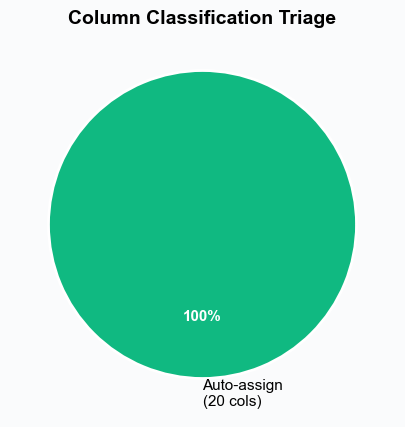

Saved images/14_triage_pie.png


In [14]:
# --- Pie chart: auto vs. review vs. unknown ---
counts = [len(auto), len(review), len(unknown)]
labels = [
    f'Auto-assign\n({counts[0]} cols)',
    f'Needs review\n({counts[1]} cols)',
    f'Unknown\n({counts[2]} cols)'
]
pie_colors = ['#10B981', '#F59E0B', '#EF4444']
# Only include non-zero slices
non_zero = [(c, l, clr) for c, l, clr in zip(counts, labels, pie_colors) if c > 0]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    [x[0] for x in non_zero],
    labels=[x[1] for x in non_zero],
    colors=[x[2] for x in non_zero],
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 11},
    pctdistance=0.6,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_color('white')

ax.set_title('Column Classification Triage', fontsize=14, fontweight='bold')

fig.savefig('images/14_triage_pie.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved images/14_triage_pie.png')

![Triage Pie](./images/14_triage_pie.png)

*Breakdown of columns by confidence level. High-confidence matches can be auto-assigned, saving significant manual effort.*

---
## 8. Confidence Score Distribution

Let's visualize how confidence scores are distributed across all the messy columns.

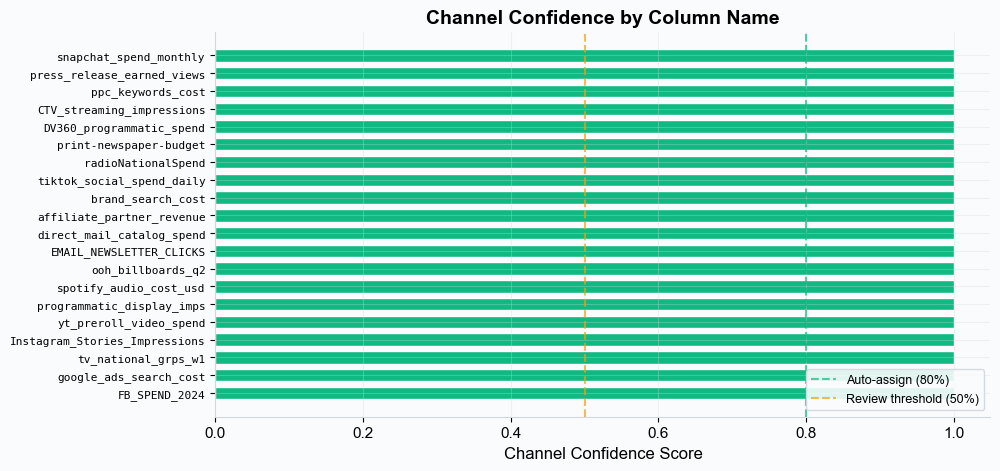

Saved images/14_confidence_bars.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

scores = messy_results['channel_confidence'].values
cols = messy_results['column'].values

# Sort by confidence
order = np.argsort(scores)[::-1]
scores_sorted = scores[order]
cols_sorted = cols[order]
bar_colors = [confidence_color(s) for s in scores_sorted]

y_pos = np.arange(len(cols_sorted))
ax.barh(y_pos, scores_sorted, color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(cols_sorted, fontsize=8, family='monospace')
ax.set_xlabel('Channel Confidence Score')
ax.set_title('Channel Confidence by Column Name')
ax.set_xlim(0, 1.05)
ax.invert_yaxis()

# Threshold lines
ax.axvline(0.80, color='#10B981', linestyle='--', alpha=0.7, label='Auto-assign (80%)')
ax.axvline(0.50, color='#F59E0B', linestyle='--', alpha=0.7, label='Review threshold (50%)')
ax.legend(loc='lower right', fontsize=9)

fig.savefig('images/14_confidence_bars.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved images/14_confidence_bars.png')

![Confidence Bars](./images/14_confidence_bars.png)

*Horizontal bar chart showing confidence scores for each column. Dashed lines mark the auto-assign and review thresholds.*

---
## 9. Extending the Matcher

Your business may have custom channel categories not covered by the standard taxonomy. Adding new categories is straightforward.

In [16]:
# Example: add Retail Media as a custom category
custom_taxonomy = dict(CHANNEL_TAXONOMY)
custom_taxonomy['Retail Media'] = [
    'walmart', 'amazon_ads', 'instacart', 'target', 'kroger',
    'retail_media', 'rma', 'shopper'
]

custom_matcher = SemanticMatcher(channel_taxonomy=custom_taxonomy)

# Test with retail media columns
retail_columns = [
    'walmart_sponsored_spend',
    'amazon_ads_display_cost',
    'instacart_impressions_q3',
    'target_retail_media_clicks',
]

retail_results = custom_matcher.classify_columns(retail_columns)
print('Custom taxonomy results:')
print()
retail_results

Custom taxonomy results:



,column,channel,channel_confidence,metric,metric_confidence
0,walmart_sponsored_spend,Retail Media,1.0,Spend,1.0
1,amazon_ads_display_cost,Display,1.0,Spend,1.0
2,instacart_impressions_q3,Retail Media,1.0,Impressions,1.0
3,target_retail_media_clicks,Retail Media,1.0,Clicks,1.0


In [17]:
# You can also add custom metric types
custom_metrics = dict(METRIC_TYPES)
custom_metrics['Conversions'] = ['conversions', 'conv', 'purchases', 'orders', 'signups']
custom_metrics['Revenue']     = ['revenue', 'sales', 'income', 'gmv']

full_matcher = SemanticMatcher(
    channel_taxonomy=custom_taxonomy,
    metric_types=custom_metrics
)

extra_cols = [
    'facebook_conversions_weekly',
    'google_ads_revenue_monthly',
    'tv_grps_national',
]

full_matcher.classify_columns(extra_cols)

,column,channel,channel_confidence,metric,metric_confidence
0,facebook_conversions_weekly,Paid Social,1.0,Conversions,1.0
1,google_ads_revenue_monthly,Paid Search,1.0,Revenue,1.0
2,tv_grps_national,TV,1.0,GRPs,1.0


### Extending tips

1. **Add domain-specific categories**: If your business uses channels like "Retail Media", "Influencer", or "Sponsorship", add them with relevant keywords.
2. **Add abbreviations**: If your team uses internal shorthand (e.g., `srch` for search), add those to the keyword lists.
3. **Adjust the confidence threshold**: Lower `min_confidence` to catch more fuzzy matches, or raise it to be more conservative.
4. **Weight exact matches higher**: You could modify `score_token` to give bonus weight to exact matches or prefix matches.

---
## 10. Summary

| Step | What we did |
|------|-------------|
| **Taxonomy** | Defined 13 channel categories + 4 metric types with keyword lists |
| **Tokenizer** | Split column names on underscores, hyphens, camelCase; strip numerics |
| **Scorer** | Three-tier scoring: exact match (1.0), substring (0.85), SequenceMatcher |
| **Classifier** | Best-match across all (token, keyword) pairs per category |
| **Triage** | High-confidence auto-assign, medium flags for review, low = unknown |
| **Extensible** | Custom categories and metrics via constructor parameters |

### Next Steps

**Related notebooks:**
- **Notebook 01** — Data Quality Checklist: validate your data before classification
- **Notebook 02** — Smart Priors from Data: use classified channels to set priors

**Documentation:**
- [Data Requirements](../docs/data/data-requirements.md) — what columns Simba expects
- [Model Configuration](../docs/platform-guide/model-configuration.md) — how classified columns feed into model setup